In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
from trees.causal_forest import CF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

s = 0.3
K = 5
w = 0.6
ns = [1000, 10000, 100000]
iterations = 10


cols = ['condition', 't', 't_est', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score', 'algorithm', 'n_observations']

scores = pd.DataFrame(columns=cols)

for n in ns:
    print(f"n: {n}")
    for exp in tqdm(range(iterations)):
        data = Data()
        data.generate(n=n, seed=exp)
        data.generate_random_condition(selectivity_threshold=s)

        ct_D = CT(data, on = "D")
        ct_D.parse_tree()

        ct_P = CT(data, on = "P")
        ct_P.parse_tree()

        cf_mse = CF(data)
        cf_mse.fit(criterion="mse", n_estimators=100)
        cf_mse.parse_forest()    

        cf_het = CF(data)
        cf_het.fit(criterion="het", n_estimators=100)
        cf_het.parse_forest() 

        for alg in [ct_D, ct_P, cf_mse, cf_het]:
            score = alg.get_topK(k=K, w=w, print_summaries=False)
            score['n_observations'] = n
            scores=pd.concat([scores, score], ignore_index=True)

        for alg in [cf_mse, cf_het]:
            alg.single_tree_interpreter()
            score = alg.get_topK(k=K, w=w, print_summaries=False)
            score['n_observations'] = n
            scores=pd.concat([scores, score], ignore_index=True)


n: 1000


100%|██████████| 10/10 [05:51<00:00, 35.12s/it]


n: 10000


100%|██████████| 10/10 [37:47<00:00, 226.70s/it]


n: 100000


100%|██████████| 10/10 [6:40:50<00:00, 2405.07s/it] 


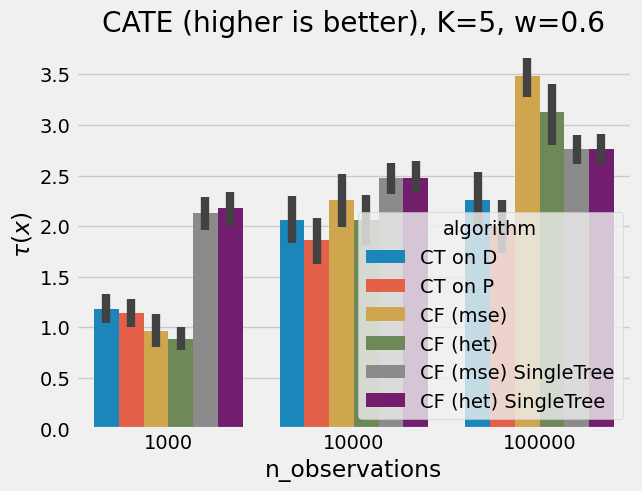

In [8]:
sns.barplot(x='n_observations', y='t', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, w={str(w)}")
plt.ylabel(r"$\tau(x)$")
plt.show()

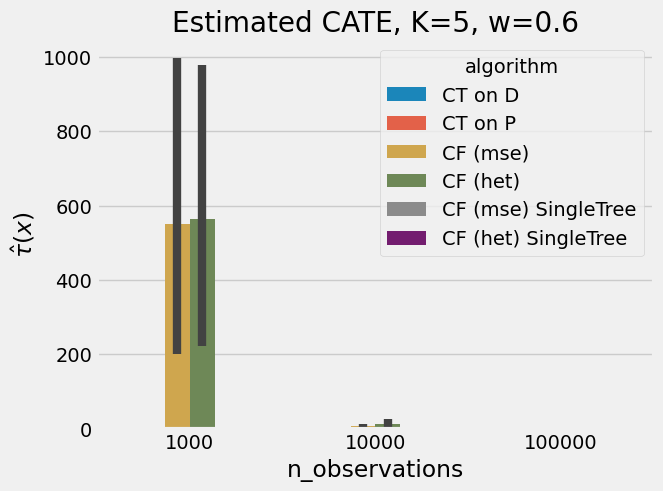

In [9]:
sns.barplot(x='n_observations', y='t_est', hue='algorithm', data=scores)
plt.title(f"Estimated CATE, K={str(K)}, w={str(w)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.show()

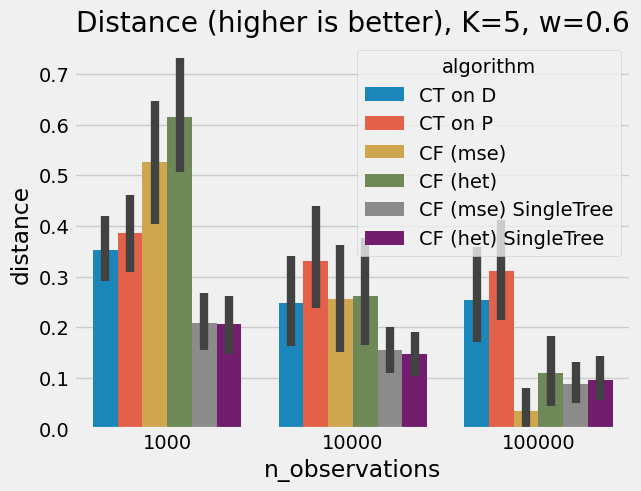

In [10]:
sns.barplot(x='n_observations', y='distance',hue="algorithm", data=scores)
plt.title(f"Distance (higher is better), K={str(K)}, w={str(w)}")
plt.show()

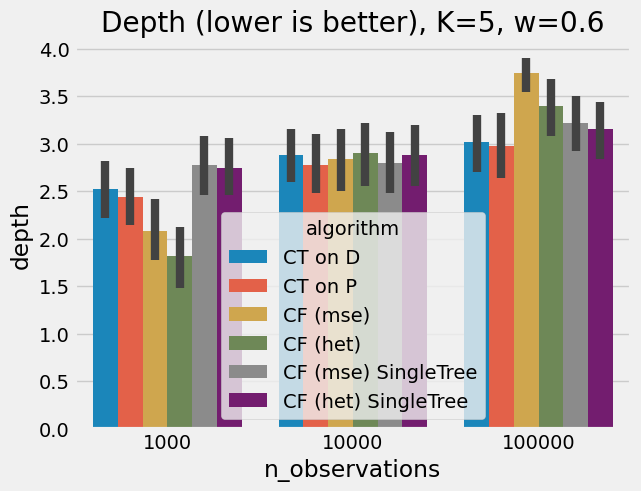

In [11]:
sns.barplot(x='n_observations', y='depth', hue="algorithm", data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, w={str(w)}")
plt.show()

In [13]:
scores

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,algorithm,n_observations,execution_time
0,feature_0 > 0.863,2.275,2.698,0.19,1.055002,3.753152,1,1.000000,0.676000,CT on D,1000,NaN
1,feature_0 <= 0.863 AND feature_1 > -0.241 AND ...,0.778,2.285,0.14,0.373534,2.658827,4,0.846924,0.564154,CT on D,1000,NaN
2,feature_0 <= 0.863 AND feature_1 <= -0.241 AND...,0.081,1.902,0.11,1.184541,-0.717720,3,0.704967,0.466980,CT on D,1000,NaN
3,feature_0 <= 0.863 AND feature_1 > -0.241 AND ...,0.799,1.339,0.33,0.423419,1.762345,3,0.496294,0.429776,CT on D,1000,NaN
4,feature_0 <= 0.863 AND feature_1 > -0.241,0.783,0.935,0.47,0.565881,1.500883,2,0.346553,0.395932,CT on D,1000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
895,feature_0 > -0.255 AND feature_0 > 0.796 AND f...,3.309,3.243,0.00,NaN,NaN,4,1.000000,0.600000,CF (het) SingleTree,100000,1036.64
896,feature_0 > -0.255 AND feature_0 > 0.796 AND f...,2.933,2.859,0.00,NaN,NaN,3,0.881591,0.528955,CF (het) SingleTree,100000,1036.64
897,feature_0 > -0.255 AND feature_0 > 0.796 AND f...,2.665,2.586,0.00,NaN,NaN,4,0.797410,0.478446,CF (het) SingleTree,100000,1036.64
898,feature_0 > -0.255 AND feature_0 > 0.796 AND f...,2.360,2.123,0.00,NaN,NaN,4,0.654641,0.392784,CF (het) SingleTree,100000,1036.64


In [15]:
import pickle as pkl

with open("N_scores.pkl", "wb") as f:
    pkl.dump(scores, f)